<a href="https://colab.research.google.com/github/HimathDissa/Unified-Logistics-Solution-CP60056E/blob/main/NorthStar_Python_Pandas_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install & Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
#Load Datasets

DATA_PATH = "."

customers  = pd.read_csv(f"{DATA_PATH}/customers.csv")
orders     = pd.read_csv(f"{DATA_PATH}/orders.csv")
deliveries = pd.read_csv(f"{DATA_PATH}/deliveries.csv")
drivers    = pd.read_csv(f"{DATA_PATH}/drivers.csv")
vehicles   = pd.read_csv(f"{DATA_PATH}/vehicles.csv")
hubs       = pd.read_csv(f"{DATA_PATH}/hubs.csv")
incidents  = pd.read_csv(f"{DATA_PATH}/incidents.csv")
complaints = pd.read_csv(f"{DATA_PATH}/complaints.csv")
app_events = pd.read_csv(f"{DATA_PATH}/app_events.csv")

print("All datasets loaded.")
for name, df in [("customers",customers),("orders",orders),("deliveries",deliveries),
                 ("drivers",drivers),("vehicles",vehicles),("hubs",hubs),
                 ("incidents",incidents),("complaints",complaints),("app_events",app_events)]:
    print(f"  {name}: {df.shape[0]} rows × {df.shape[1]} cols")

All datasets loaded.
  customers: 650 rows × 9 cols
  orders: 1250 rows × 11 cols
  deliveries: 950 rows × 13 cols
  drivers: 170 rows × 8 cols
  vehicles: 120 rows × 8 cols
  hubs: 8 rows × 5 cols
  incidents: 280 rows × 7 cols
  complaints: 320 rows × 10 cols
  app_events: 640 rows × 10 cols



=== STEP 1: Missing Value Analysis ===
   dataset                        column  missing_count  missing_pct
 customers                 loyalty_score             20          3.1
 customers             preferred_channel             13          2.0
    orders               booking_channel             25          2.0
deliveries         delivery_completed_at             19          2.0
deliveries customer_rating_post_delivery             14          1.5
   drivers                training_score              7          4.1
  vehicles            battery_health_pct              4          3.3
 incidents                resolved_hours             17          6.1
complaints           compensation_amount             16          5.0
app_events                      order_id            144         22.5


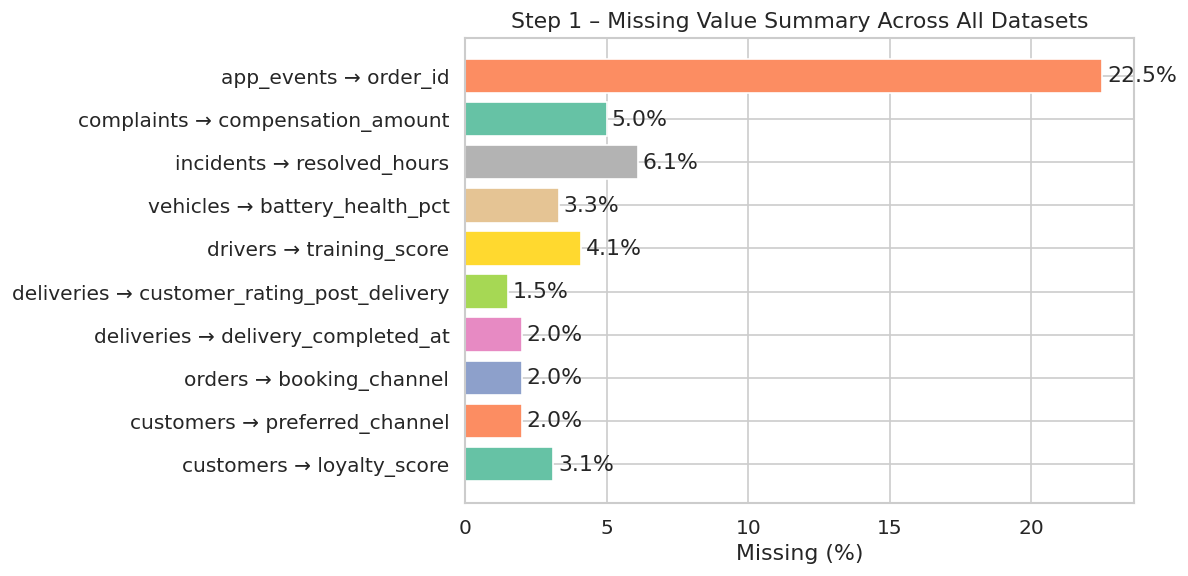

In [ ]:
#1 - MISSING VALUE ANALYSIS

print("\n=== STEP 1: Missing Value Analysis ===")

datasets = {
    "customers": customers, "orders": orders, "deliveries": deliveries,
    "drivers": drivers, "vehicles": vehicles, "incidents": incidents,
    "complaints": complaints, "app_events": app_events
}

missing_summary = []
for name, df in datasets.items():
    for col in df.columns:
        n_miss = df[col].isnull().sum()
        if n_miss > 0:
            missing_summary.append({
                "dataset": name,
                "column": col,
                "missing_count": n_miss,
                "missing_pct": round(100 * n_miss / len(df), 1)
            })

missing_df = pd.DataFrame(missing_summary)
print(missing_df.to_string(index=False))

# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(missing_df))
bars = ax.barh(
    missing_df["dataset"] + " → " + missing_df["column"],
    missing_df["missing_pct"], color=colors
)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in missing_df["missing_pct"]], padding=3)
ax.set_xlabel("Missing (%)")
ax.set_title("Step 1 – Missing Value Summary Across All Datasets")
plt.tight_layout()
plt.show()

In [ ]:
#2 - Data Cleaning

print("\n=== STEP 2: Data Cleaning ===")

# --- 2a. Standardise zone names (raw data has north/NORTH/North/Ctr/CENTRAL) ---
ZONE_MAP = {
    "north": "North", "NORTH": "North",
    "south": "South", "SOUTH": "South",
    "east":  "East",  "EAST":  "East",
    "west":  "West",  "WEST":  "West",
    "central": "Central", "CENTRAL": "Central", "Ctr": "Central", "CTR": "Central",
    "airport": "Airport", "AIRPORT": "Airport",
    "riverside": "Riverside", "RIVERSIDE": "Riverside", "RiverSide": "Riverside"
}

def clean_zone(series):
    return series.str.strip().replace(ZONE_MAP)

orders["pickup_zone"]      = clean_zone(orders["pickup_zone"])
orders["dropoff_zone"]     = clean_zone(orders["dropoff_zone"])
customers["home_zone"]     = clean_zone(customers["home_zone"])
drivers["base_zone"]       = clean_zone(drivers["base_zone"])
vehicles["assigned_zone"]  = clean_zone(vehicles["assigned_zone"])
hubs["zone"]               = clean_zone(hubs["zone"])
app_events["zone_context"] = clean_zone(app_events["zone_context"])

print("Zone names standardised. Unique pickup zones now:", sorted(orders["pickup_zone"].unique()))

# --- 2b. Impute missing numeric values ---
# loyalty_score → median imputation (robust to outliers)
median_loyalty = customers["loyalty_score"].median()
customers["loyalty_score"].fillna(median_loyalty, inplace=True)
print(f"loyalty_score: filled {missing_df.loc[missing_df['column']=='loyalty_score','missing_count'].values[0]} NAs with median ({median_loyalty})")

# training_score → median per employment_type (more precise)
drivers["training_score"] = drivers.groupby("employment_type")["training_score"] \
    .transform(lambda x: x.fillna(x.median()))
print("training_score: filled NAs with median per employment_type")

# battery_health_pct → median per vehicle_type
vehicles["battery_health_pct"] = vehicles.groupby("vehicle_type")["battery_health_pct"] \
    .transform(lambda x: x.fillna(x.median()))
print("battery_health_pct: filled NAs with median per vehicle_type")

# compensation_amount → 0 where missing (no compensation was given)
complaints["compensation_amount"].fillna(0, inplace=True)
print("compensation_amount: filled NAs with 0 (no compensation awarded)")

# resolved_hours → median (incident still open; we note separately)
median_resolved = incidents["resolved_hours"].median()
incidents["resolved_hours"].fillna(median_resolved, inplace=True)
print(f"resolved_hours: filled NAs with median ({median_resolved})")

# preferred_channel → mode
mode_channel = customers["preferred_channel"].mode()[0]
customers["preferred_channel"].fillna(mode_channel, inplace=True)

# booking_channel → mode
mode_booking = orders["booking_channel"].mode()[0]
orders["booking_channel"].fillna(mode_booking, inplace=True)

# --- 2c. Parse datetime columns ---
deliveries["dispatch_time"]         = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])
orders["order_created_at"]          = pd.to_datetime(orders["order_created_at"])
app_events["event_timestamp"]       = pd.to_datetime(app_events["event_timestamp"])
customers["signup_date"]            = pd.to_datetime(customers["signup_date"])

print("\nDatetime columns parsed.")
print("Data cleaning complete — no missing values remain in key columns.\n")


=== STEP 2: Data Cleaning ===
Zone names standardised. Unique pickup zones now: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
loyalty_score: filled 20 NAs with median (59.6)
training_score: filled NAs with median per employment_type
battery_health_pct: filled NAs with median per vehicle_type
compensation_amount: filled NAs with 0 (no compensation awarded)
resolved_hours: filled NAs with median (11.5)

Datetime columns parsed.
Data cleaning complete — no missing values remain in key columns.



/tmp/ipykernel_5438/905177086.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers["loyalty_score"].fillna(median_loyalty, inplace=True)
/tmp/ipykernel_5438/905177086.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
#3 - Feature Engineering

print("=== STEP 3: Feature Engineering ===")

# Delivery duration in hours
deliveries["actual_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600
# Remove anomalies
deliveries.loc[deliveries["actual_duration_hrs"] < 0,  "actual_duration_hrs"] = np.nan
deliveries.loc[deliveries["actual_duration_hrs"] > 72, "actual_duration_hrs"] = np.nan

# Delivery hour of day (for peak analysis)
deliveries["dispatch_hour"] = deliveries["dispatch_time"].dt.hour

# Order month and day of week
orders["order_month"]   = orders["order_created_at"].dt.to_period("M").astype(str)
orders["order_dow"]     = orders["order_created_at"].dt.day_name()
orders["order_hour"]    = orders["order_created_at"].dt.hour

# Customer tenure in days
customers["tenure_days"] = (pd.Timestamp("today") - customers["signup_date"]).dt.days

# Failure flag on deliveries
deliveries["is_failure"] = deliveries["delivery_status"].isin(["Failed", "Delayed"]).astype(int)

# High severity complaint flag
complaints["is_high_severity"] = complaints["severity"].isin(["High", "Critical"]).astype(int)

print("New features created:")
print("  deliveries: actual_duration_hrs, dispatch_hour, is_failure")
print("  orders:     order_month, order_dow, order_hour")
print("  customers:  tenure_days")
print("  complaints: is_high_severity\n")

=== STEP 3: Feature Engineering ===
New features created:
  deliveries: actual_duration_hrs, dispatch_hour, is_failure
  orders:     order_month, order_dow, order_hour
  customers:  tenure_days
  complaints: is_high_severity



In [ ]:
#4 - Build Master Analytical Table

master = (
    deliveries
    .merge(orders,     on="order_id",    how="left")
    .merge(drivers,    on="driver_id",   how="left")
    .merge(vehicles,   on="vehicle_id",  how="left")
    .merge(customers,  on="customer_id", how="left")
    .merge(hubs,       on="hub_id",      how="left")
)

print(f"=== STEP 4: Master table: {master.shape[0]} rows × {master.shape[1]} cols ===\n")

=== STEP 4: Master table: 950 rows × 56 cols ===



=== ANALYSIS 1: Failure Heatmap – Zone × Service Type ===
service_type  Business  Medical  Parcel  Passenger  Retail
pickup_zone                                               
Airport           38.5     40.0    29.0       50.0    34.5
Central           54.2     46.2    46.3       40.4    55.1
East              38.9     21.1    30.0       37.8    29.4
North             39.1     50.0    22.2       17.1    40.6
Riverside         35.3     28.6    39.3       42.4    29.6
South             52.6     29.4    28.1       17.5    16.1
West              25.0     35.3    25.8       40.6    22.7


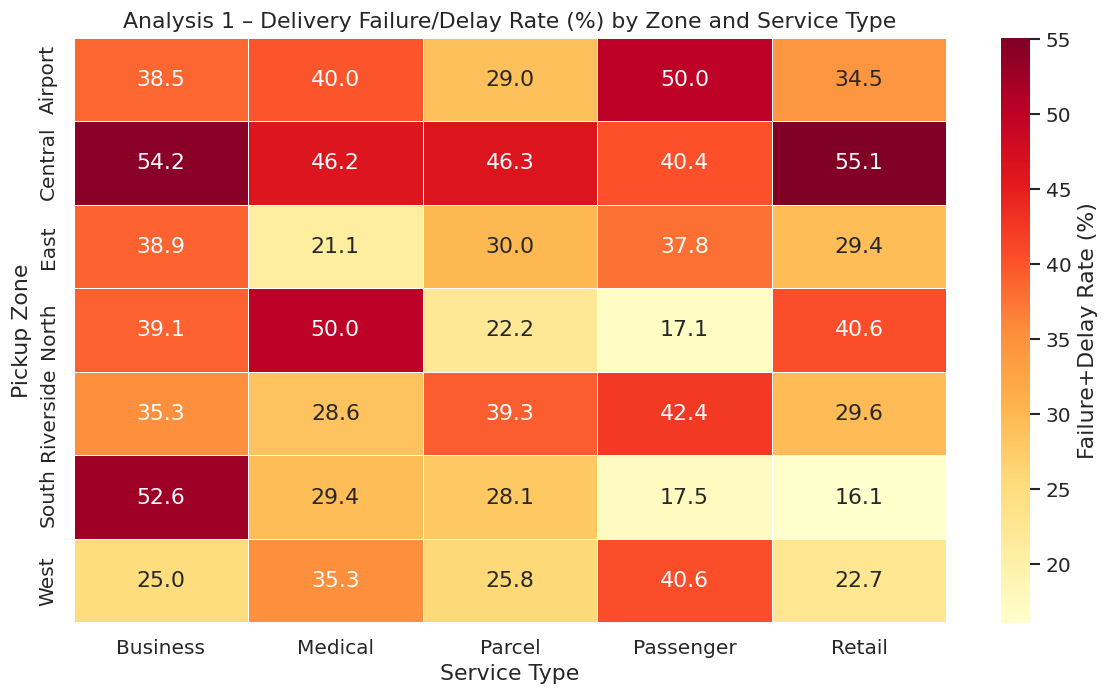

In [ ]:
#Analysis 1 - Failure Rate by Zone & Service Type

print("=== ANALYSIS 1: Failure Heatmap – Zone × Service Type ===")

failure_heat = (
    master.groupby(["pickup_zone", "service_type"])["is_failure"]
    .mean()
    .mul(100).round(1)
    .reset_index()
    .pivot(index="pickup_zone", columns="service_type", values="is_failure")
)

print(failure_heat)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(failure_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Failure+Delay Rate (%)"})
ax.set_title("Analysis 1 – Delivery Failure/Delay Rate (%) by Zone and Service Type")
ax.set_xlabel("Service Type")
ax.set_ylabel("Pickup Zone")
plt.tight_layout()
plt.show()